<a href="https://colab.research.google.com/github/KavinduJ2001/segment-anything/blob/reproduction-experiments/SAM_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segment Anything - SAM**

### **Section 1: Environment Setup & Dependencies**

In this section, we set up the environment by installing the segment-anything library directly from the source, mounting Google Drive for persistent storage, and defining the helper functions for visualization

In [40]:
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL = "https://github.com/KavinduJ2001/segment-anything"

if not os.path.exists("segment-anything"):
    !git clone {REPO_URL}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'segment-anything'...
remote: Enumerating objects: 293, done.
remote: Total 293 (delta 0), reused 0 (delta 0), pack-reused 293 (from 1)
Receiving objects: 100% (293/293), 18.31 MiB | 27.21 MiB/s, done.
Resolving deltas: 100% (151/151), done.


In [41]:
%cd segment-anything

/content/segment-anything/segment-anything


In [42]:
!pip install -q -e .
!pip install -q opencv-python pycocotools matplotlib onnxruntime supervision

  Preparing metadata (setup.py) ... done


In [43]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json


### **Model Loading & Initialization**

Here we initialize the SAM architecture. We load the ViT-H (Huge) checkpoint, which contains 632M parameters, and move it to the GPU for efficient inference.

In [44]:
CHECKPOINT_MAP = {
    "vit_h": "/content/drive/MyDrive/SAM/SAM 1/sam_vit_h_4b8939.pth", # Huge (Best Quality)
    "vit_l": "/content/drive/MyDrive/SAM/SAM 1/sam_vit_l_0b3195.pth", # Large
    "vit_b": "/content/drive/MyDrive/SAM/SAM 1/sam_vit_b_01ec64.pth", # Base (Fastest)
}

In [45]:
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = CHECKPOINT_MAP[MODEL_TYPE]

if os.path.exists(CHECKPOINT_PATH):
    print(f"Found checkpoint at: {CHECKPOINT_PATH}")
else:
    print(f"ERROR: File not found at {CHECKPOINT_PATH}")
    print("Please check your Drive folders and update the path above.")

Found checkpoint at: /content/drive/MyDrive/SAM/SAM 1/sam_vit_h_4b8939.pth


In [46]:
import torch
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_TYPE} model on {device}...")

try:
    sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
    sam.to(device=device)
    predictor = SamPredictor(sam)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Failed to load model: {e}")

Loading vit_h model on cpu...
Model loaded successfully!


### **Section 3: Image Preprocessing**

SAM requires images in RGB format. We load the test image using OpenCV and convert it from BGR to RGB to ensure color accuracy during feature extraction.

In [47]:
import gradio as gr
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [48]:

import cv2

!wget -q -O truck.jpg https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg

image = cv2.imread('truck.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image) #image embedding


In [49]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


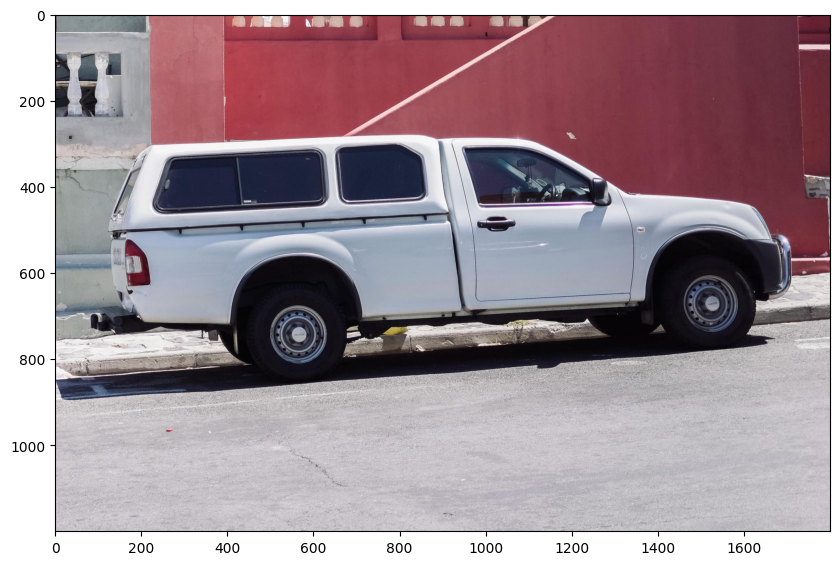

In [50]:
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show()

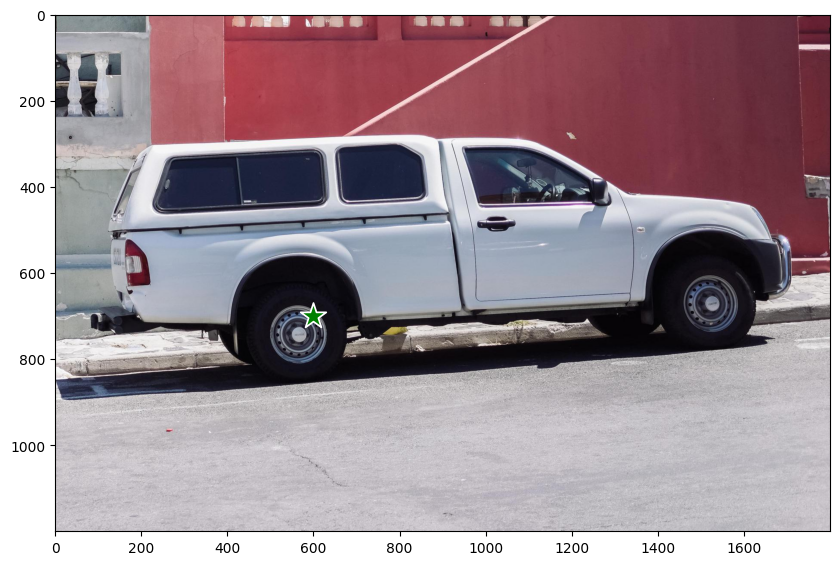

In [51]:
input_point = np.array([[600, 700]])
input_label = np.array([1])

plt.figure(figsize=(10,10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

### **Section 4: Prompt Engineering - Point Interactions**

This experiment demonstrates Promptable Segmentation. We provide a single (x,y) coordinate as a positive prompt. We also visualize the 'Ambiguity Awareness' of SAM by generating 3 masks (Sub-part, Part, Whole) from a single click.

Point Prompt: Generated 3 masks.


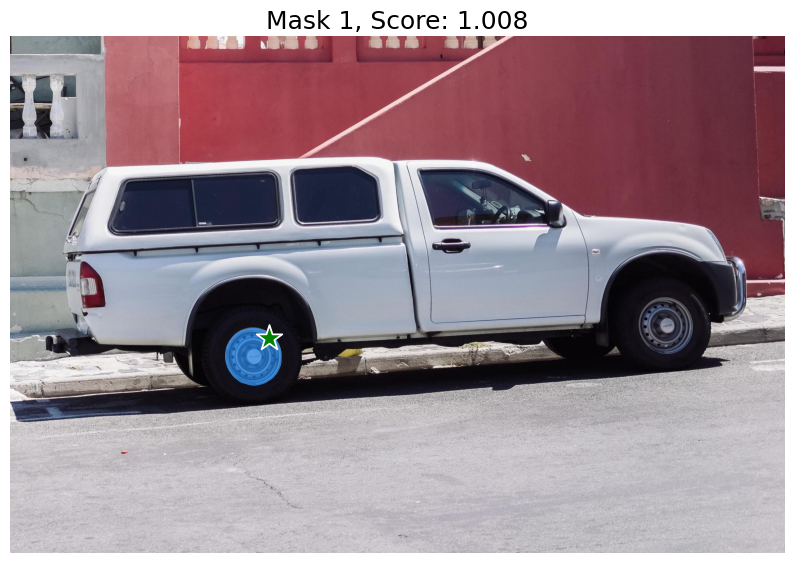

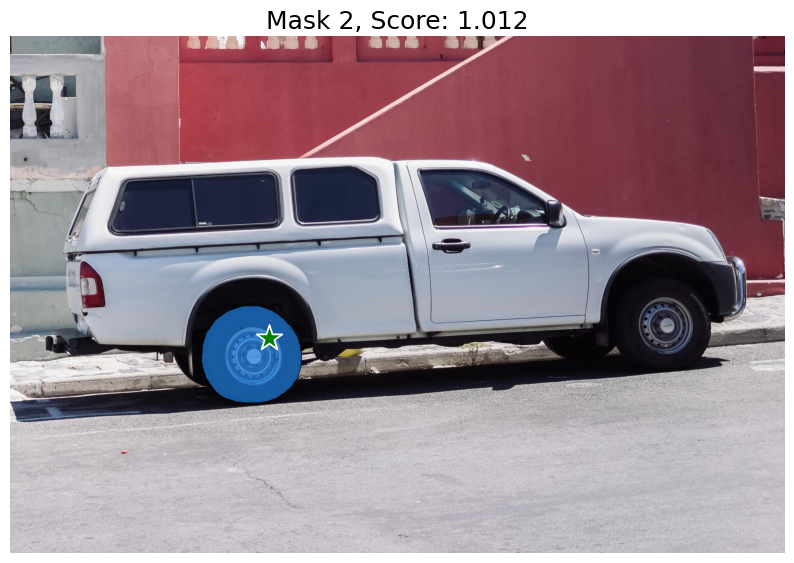

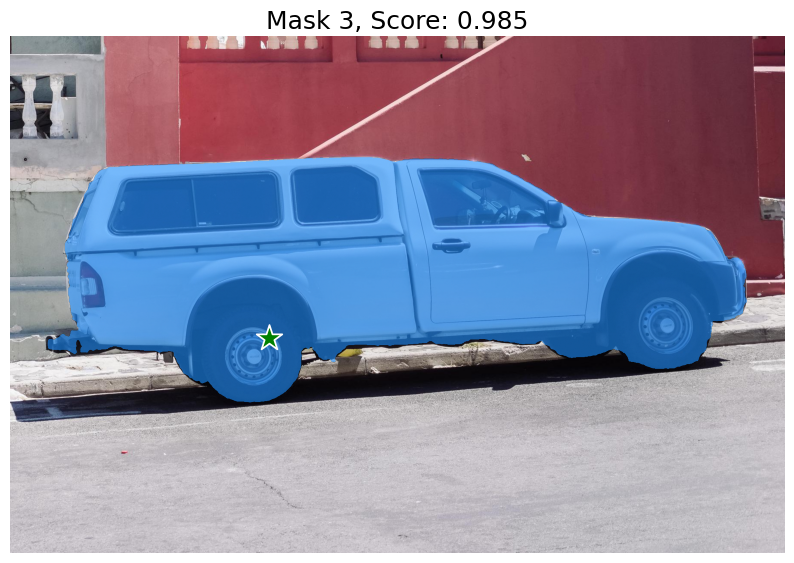

In [52]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True, # Show ambiguity
)

print(f"Point Prompt: Generated {len(masks)} masks.")

for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis('off')
    plt.show()

### **Multiple Positive Points**

In [53]:
input_point = np.array([[600, 700], [1125, 625]])
input_label = np.array([1, 1])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

In [54]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

masks.shape

(1, 1200, 1800)

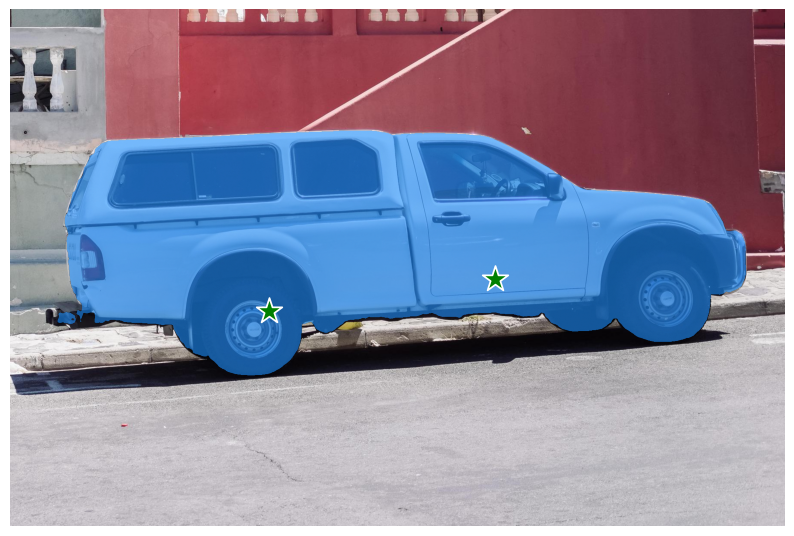

In [55]:
plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

### **Foreground vs. Background (Exclusion)**

Demonstrating SAM's ability to understand Negative Constraints. We give one positive point (Foreground, Label 1) on the truck and one negative point (Background, Label 0) on the background area. This forces the model to snap the mask tightly to the boundary.

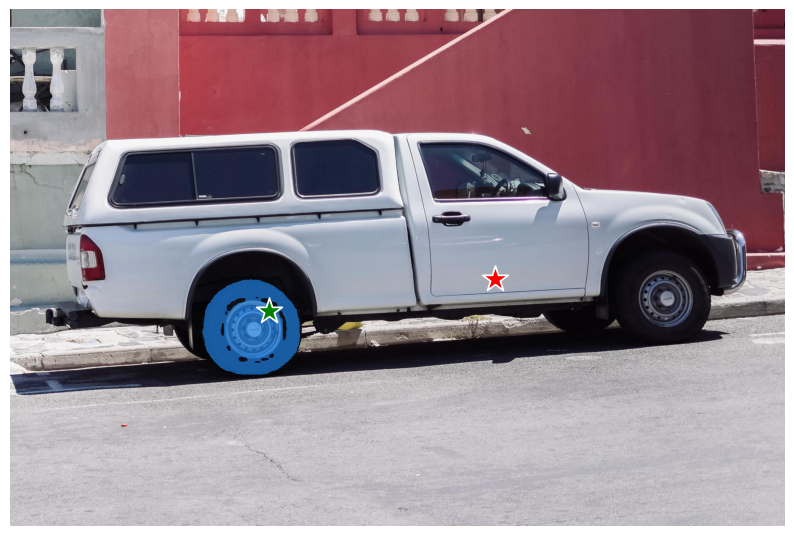

In [56]:
input_point = np.array([[600, 700], [1125, 625]])
input_label = np.array([1, 0])

mask_input = logits[np.argmax(scores), :, :]  # Choose the model's best mask

masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    mask_input=mask_input[None, :, :],
    multimask_output=False,
)

masks.shape

plt.figure(figsize=(10,10))
plt.imshow(image)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

### **Interactive "Click-to-Segment" Demo**

This is an Interactive Inference Loop. Using a Gradio interface, we simulate a real-world annotation tool where the user can click anywhere on the image, and the model generates masks in real-time.

In [65]:
# True  = Show 3 Ambiguity Options (Sub-part, Part, Whole)
# False = Show 1 Best Mask (Standard)
SHOW_AMBIGUITY = True

clicked_points = []
clicked_labels = []

def segment_robust(image, evt: gr.SelectData):
    global clicked_points, clicked_labels, SHOW_AMBIGUITY

    # Update Memory
    x, y = evt.index
    clicked_points.append([x, y])
    clicked_labels.append(1)

    # Run SAM
    predictor.set_image(image)
    masks, scores, _ = predictor.predict(
        point_coords=np.array(clicked_points),
        point_labels=np.array(clicked_labels),
        multimask_output=SHOW_AMBIGUITY,
    )

    # SMART VISUALIZATION
    num_masks = len(masks)
    h, w, _ = image.shape

    combined_result = np.zeros((h, w * num_masks, 3), dtype=np.uint8)

    if num_masks == 3:
        titles = ["Option 1 (Sub-part)", "Option 2 (Part)", "Option 3 (Whole)"]
    else:
        titles = ["Best Match"]

    for i in range(num_masks):
        viz = image.copy()

        # Apply Mask
        mask = masks[i]
        colored_mask = np.zeros_like(viz)
        colored_mask[mask] = [0, 255, 0] # Green
        viz = cv2.addWeighted(viz, 1, colored_mask, 0.5, 0)

        # Draw all clicks
        for pt in clicked_points:
            cv2.circle(viz, (pt[0], pt[1]), 10, (0, 0, 255), -1)

        text = f"{titles[i]} ({scores[i]:.2f})"
        cv2.putText(viz, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1.5, (255, 255, 255), 3)

        combined_result[:, i*w : (i+1)*w, :] = viz

    return combined_result

def clear_memory():
    global clicked_points, clicked_labels
    clicked_points = []
    clicked_labels = []
    return None

with gr.Blocks() as demo:
    gr.Markdown("# SAM Inspector")
    gr.Markdown(f"Current Mode: **{'Ambiguity (3 Masks)' if SHOW_AMBIGUITY else 'Standard (1 Mask)'}**")

    with gr.Row():
        inp = gr.Image(label="Input", type="numpy")
        out = gr.Image(label="Output (Dynamic Size)")

    btn_clear = gr.Button("🗑️ Clear Points")

    inp.select(segment_robust, inp, out)
    btn_clear.click(clear_memory, outputs=out)

demo.launch(debug=False, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77b111516859f3c628.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### **Section 5: Prompt Engineering - Bounding Box Interactions**

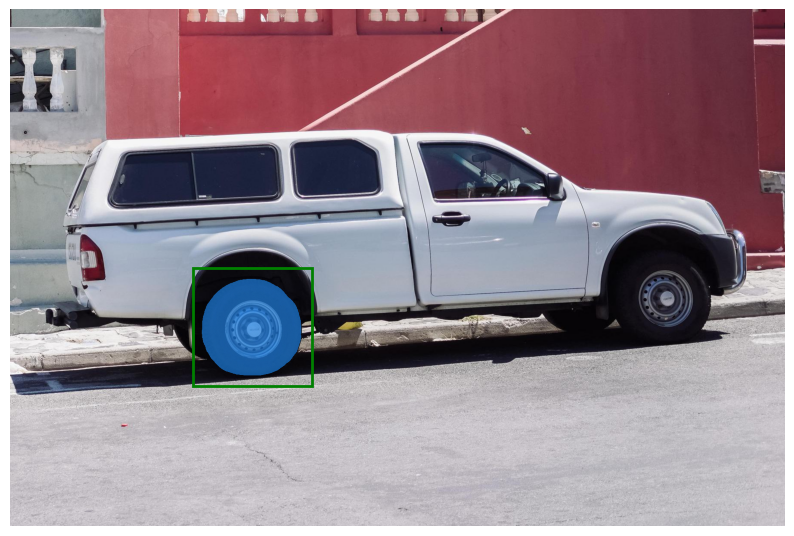

In [57]:
input_box = np.array([425, 600, 700, 875])

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
plt.axis('off')
plt.show()

### **Interactive bounding box selection**

In [66]:
import base64
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output
from jupyter_bbox_widget import BBoxWidget

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        data = f.read()
    encoded = str(base64.b64encode(data), 'utf-8')
    return "data:image/jpg;base64,"+encoded

def show_mask(mask, ax, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

In [67]:
# Setup the Widget
widget = BBoxWidget()
widget.image = encode_image("truck.jpg")
widget.classes = ['Object']

# Create an Output Area (To stop images from piling up)
out = widgets.Output()

# Define the Logic
def on_box_submit():
    with out:
        clear_output(wait=True)

        if len(widget.bboxes) == 0:
            print("⚠️ Please draw at least one box.")
            return

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        ax = plt.gca()

        print(f"✅ Found {len(widget.bboxes)} boxes. Segmenting...")

        for bbox in widget.bboxes:
            box_array = np.array([
                bbox['x'],
                bbox['y'],
                bbox['x'] + bbox['width'],
                bbox['y'] + bbox['height']
            ])

            masks, _, _ = predictor.predict(
                point_coords=None,
                point_labels=None,
                box=box_array[None, :],
                multimask_output=False,
            )

            show_mask(masks[0], ax, random_color=True) # Random color helps distinguish objects

            # Draw the box outline
            x0, y0, x1, y1 = box_array
            ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, edgecolor='white', facecolor='none', lw=2))

        plt.axis('off')
        plt.title(f"Multi-Box Segmentation ({len(widget.bboxes)} Objects)")
        plt.show()

# Connect and Display
widget.on_submit(on_box_submit)

print("👇 Draw MULTIPLE boxes, then click 'Submit'")
display(widget, out)

👇 Draw MULTIPLE boxes, then click 'Submit'


Output()

### **Section 6: Multi-Prompt Integration**

We test SAM's ability to handle Compound Prompts. By providing both a box and a specific exclusion point (Label 0), we guide the model to segment an object while explicitly ignoring a specific sub-region.

In [58]:
input_box = np.array([425, 600, 700, 875])
input_point = np.array([[575, 750]])
input_label = np.array([0])

In [59]:
masks, _, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    box=input_box,
    multimask_output=False,
)

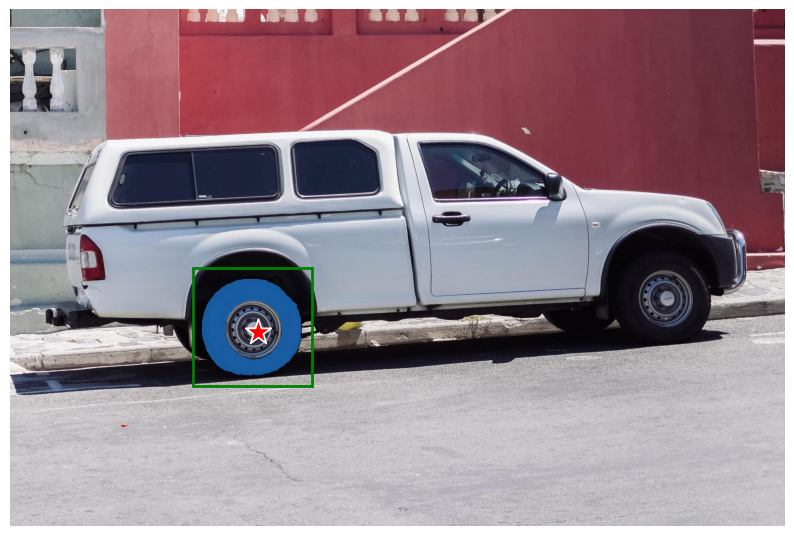

In [60]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_mask(masks[0], plt.gca())
show_box(input_box, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show()

### **Section 7: Batched Prompts (Object Detector Simulation)**

In a real-world pipeline, an object detector (like YOLO or DINO) might detect multiple objects in a single frame. Instead of running inference in a loop (slow), we use predict_torch to process a Batch of Bounding Boxes simultaneously.

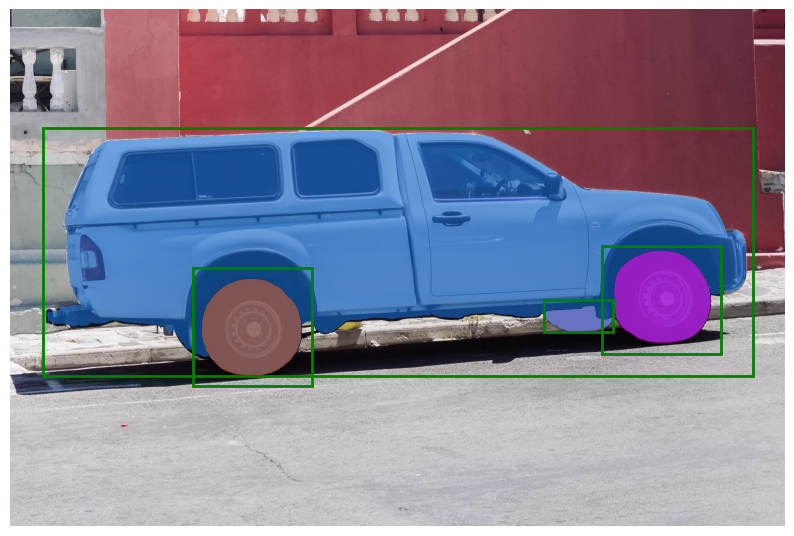

In [61]:
input_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=predictor.device)

transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False,
)
masks.shape  # (batch_size) x (num_predicted_masks_per_input) x H x W

plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)
for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())
plt.axis('off')
plt.show()

###**Section 8: Batch Inference (High-Throughput)**

This section demonstrates the End-to-End Inference mode designed for batch processing. Unlike the interactive SamPredictor, this method processes multiple images and prompts in parallel

In [62]:
image1 = image  # truck.jpg from above
image1_boxes = torch.tensor([
    [75, 275, 1725, 850],
    [425, 600, 700, 875],
    [1375, 550, 1650, 800],
    [1240, 675, 1400, 750],
], device=sam.device)

!wget -q -O groceries.jpg https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg

image2 = cv2.imread('groceries.jpg')
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image2_boxes = torch.tensor([
    [450, 170, 520, 350],
    [350, 190, 450, 350],
    [500, 170, 580, 350],
    [580, 170, 640, 350],
], device=sam.device)

Both images and prompts are input as PyTorch tensors that are already transformed to the correct frame. Inputs are packaged as a list over images, which each element is a dict that takes the following keys:
* `image`: The input image as a PyTorch tensor in CHW format.
* `original_size`: The size of the image before transforming for input to SAM, in (H, W) format.
* `point_coords`: Batched coordinates of point prompts.
* `point_labels`: Batched labels of point prompts.
* `boxes`: Batched input boxes.
* `mask_inputs`: Batched input masks.

If a prompt is not present, the key can be excluded.

In [63]:
from segment_anything.utils.transforms import ResizeLongestSide
resize_transform = ResizeLongestSide(sam.image_encoder.img_size)

def prepare_image(image, transform, device):
    image = transform.apply_image(image)
    image = torch.as_tensor(image, device=device.device)
    return image.permute(2, 0, 1).contiguous()

In [64]:
batched_input = [
     {
         'image': prepare_image(image1, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image1_boxes, image1.shape[:2]),
         'original_size': image1.shape[:2]
     },
     {
         'image': prepare_image(image2, resize_transform, sam),
         'boxes': resize_transform.apply_boxes_torch(image2_boxes, image2.shape[:2]),
         'original_size': image2.shape[:2]
     }
]

In [34]:
batched_output = sam(batched_input, multimask_output=False)

The output is a list over results for each input image, where list elements are dictionaries with the following keys:
* `masks`: A batched torch tensor of predicted binary masks, the size of the original image.
* `iou_predictions`: The model's prediction of the quality for each mask.
* `low_res_logits`: Low res logits for each mask, which can be passed back to the model as mask input on a later iteration.

In [35]:
batched_output[0].keys()

dict_keys(['masks', 'iou_predictions', 'low_res_logits'])

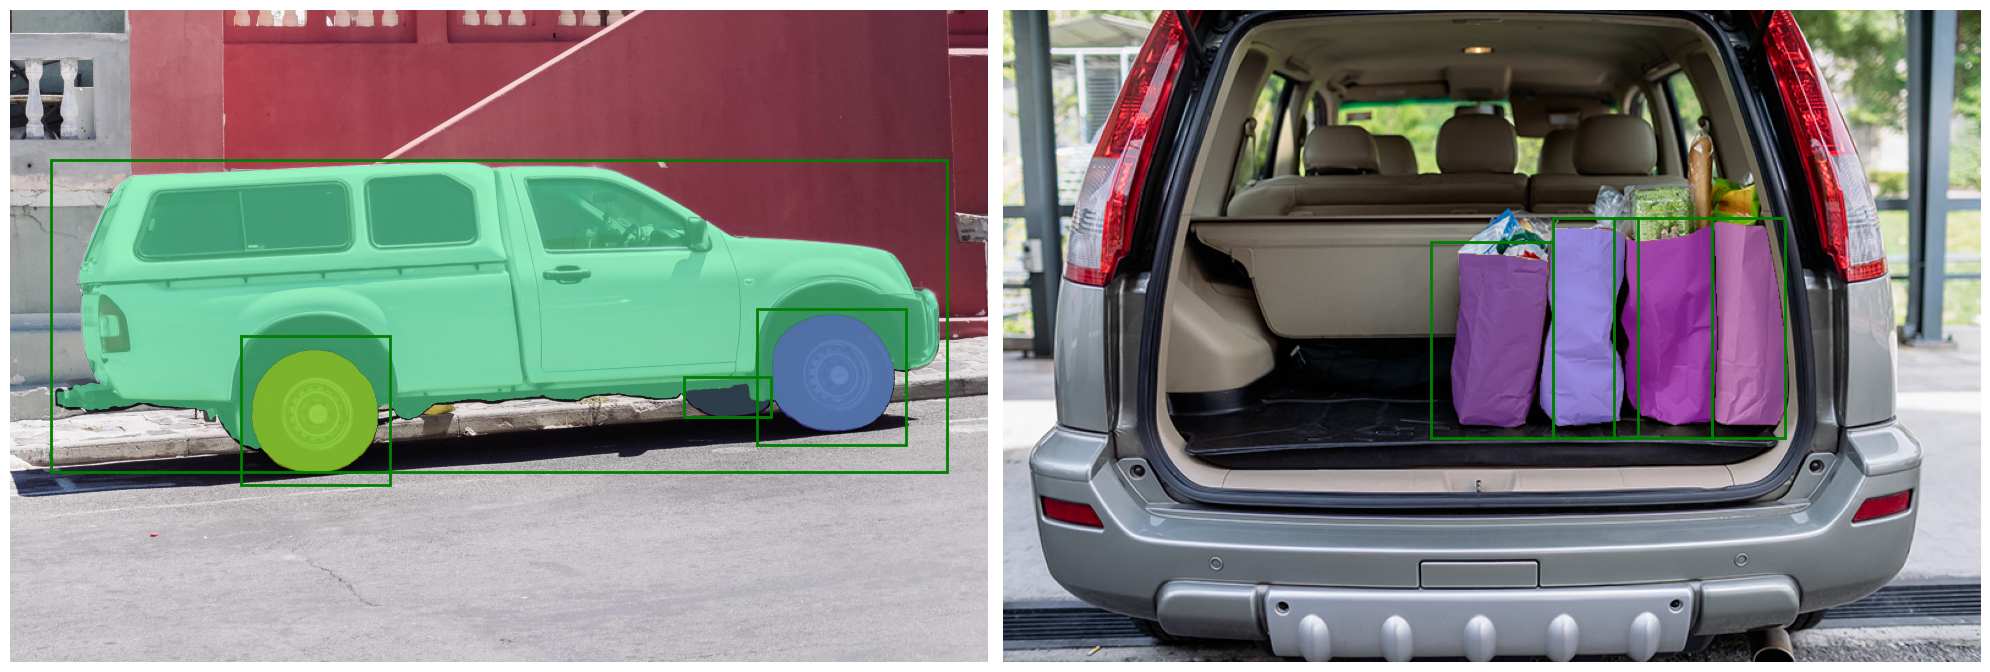

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(20, 20))

ax[0].imshow(image1)
for mask in batched_output[0]['masks']:
    show_mask(mask.cpu().numpy(), ax[0], random_color=True)
for box in image1_boxes:
    show_box(box.cpu().numpy(), ax[0])
ax[0].axis('off')

ax[1].imshow(image2)
for mask in batched_output[1]['masks']:
    show_mask(mask.cpu().numpy(), ax[1], random_color=True)
for box in image2_boxes:
    show_box(box.cpu().numpy(), ax[1])
ax[1].axis('off')

plt.tight_layout()
plt.show()

### **Section 9: Automatic Mask Generation (Zero-Shot)**

Reproducing the Zero-Shot Segment Everything capability. The model automatically generates a 32x32 grid of point prompts to discover and segment every object in the image without human intervention.

Running Automatic Segmentation...
Found 77 masks.


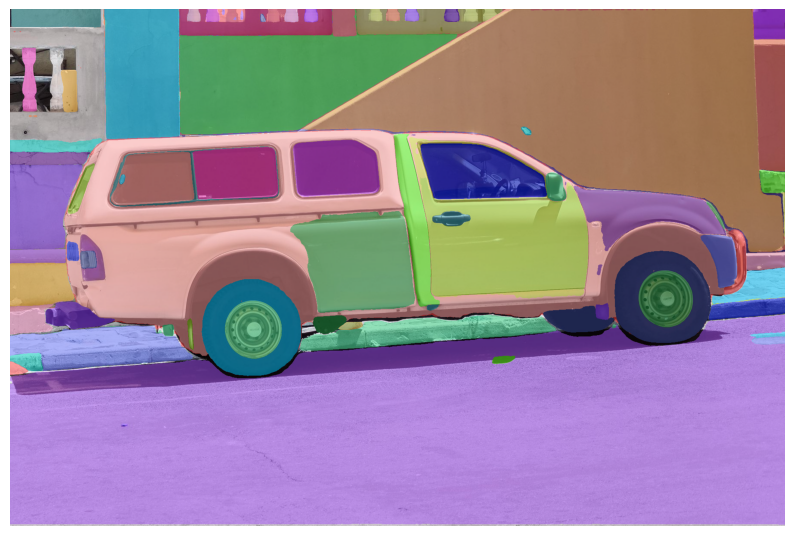

In [37]:
# --- SECTION 3: AUTOMATIC MASK GENERATOR ---
from segment_anything import SamAutomaticMaskGenerator
import supervision as sv

# 1. Initialize Generator
mask_generator = SamAutomaticMaskGenerator(sam)

# 2. Generate Masks
print("Running Automatic Segmentation...")
masks = mask_generator.generate(image)

# 3. Visualize
print(f"Found {len(masks)} masks.")
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_sam(sam_result=masks)
annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

### **Section 10: Tuned Automatic Generation**

In this section, we fine-tune the `SamAutomaticMaskGenerator` to improve mask quality.

* **`points_per_side=32` (Grid Density)**
    * Sets the sampling grid to 32x32 (1,024 total points). Each point acts as a prompt. Higher numbers find smaller objects but run slower.

* **`pred_iou_thresh=0.86` (Quality Filter)**
    * Filters out masks where the model's confidence is low. Only keeps masks with >86% predicted quality score.

* **`stability_score_thresh=0.92` (Stability Filter)**
    * Ensures mask boundaries are solid. If a mask shape changes drastically with minor threshold adjustments (jitter), it is discarded as "unstable" noise.

* **`crop_n_layers=1` (Zoom-In / Multi-Scale)**
    * Cuts the image into smaller crops (1 layer = 4 crops) and runs inference again to find tiny details.
    * *(Note: Set to 0 on CPU to prevent long wait times).*

* **`crop_n_points_downscale_factor=2`**
    * Reduces the grid density by 2x when running on the smaller cropped images to save computation time.

* **`min_mask_region_area=100` (Post-Processing)**
    * Removes any unconnected mask regions smaller than 100 pixels to clean up background noise.

In [38]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1, #set to zero if on CPU
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)

masks2 = mask_generator_2.generate(image)

len(masks2)

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show()